# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import catboost
from sklearn.metrics import mean_absolute_error, mean_absolute_error, r2_score
import lightgbm
import math
import holidays


# Load data

In [2]:
sales = pd.read_csv('sales.csv',parse_dates = ['Date'])
test = pd.read_csv('sample_submission.csv',parse_dates =['Date'])

In [3]:
print(f"Data train period from {sales['Date'].min().date()} to {sales['Date'].max().date()}")
print(f"Data test period from {test['Date'].min().date()} to {test['Date'].max().date()}")

Data train period from 2012-07-04 to 2022-12-31
Data test period from 2023-01-01 to 2024-07-01


In [4]:
df_sale = sales.copy()
df_sale['is_test'] = 0
df_test = test.copy()
df_test['is_test'] = 1
df = pd.concat([df_sale,df_test], ignore_index= True)

# EDA data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4381 entries, 0 to 4380
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     4381 non-null   datetime64[ns]
 1   Revenue  4381 non-null   float64       
 2   COGS     4381 non-null   float64       
 3   is_test  4381 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 137.0 KB


In [6]:
round(df.describe(),2)

,Date,Revenue,COGS,is_test
count,4381,4381.00,4381.00,4381.00
mean,2018-07-03 00:00:00,4156896.71,3581140.94,0.13
min,2012-07-04 00:00:00,279813.94,236576.31,0.00
25%,2015-07-04 00:00:00,2402388.27,2092259.75,0.00
50%,2018-07-03 00:00:00,3555473.95,3072656.32,0.00
75%,2021-07-02 00:00:00,5156699.45,4439845.57,0.00
max,2024-07-01 00:00:00,20905271.35,16535857.67,1.00
std,NaN,2541235.58,2152436.91,0.33


<Figure size 1500x1000 with 0 Axes>

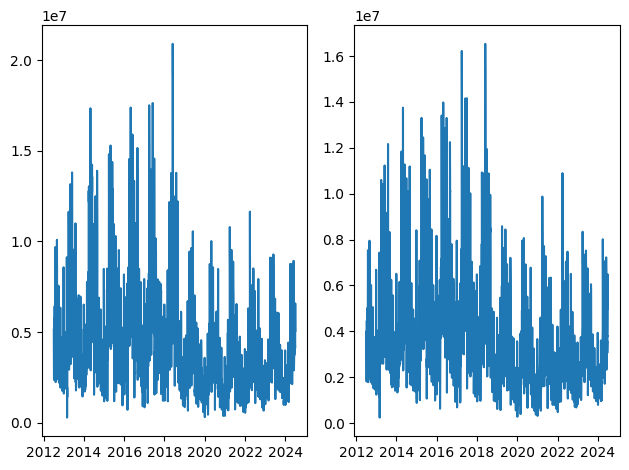

In [7]:
plt.figure(figsize= (15,10))
fig,ax = plt.subplots(nrows=1,ncols=2 )

ax[0].plot(df['Date'],df['Revenue'])
ax[1].plot(df['Date'],df['COGS'])
plt.tight_layout(
    
)

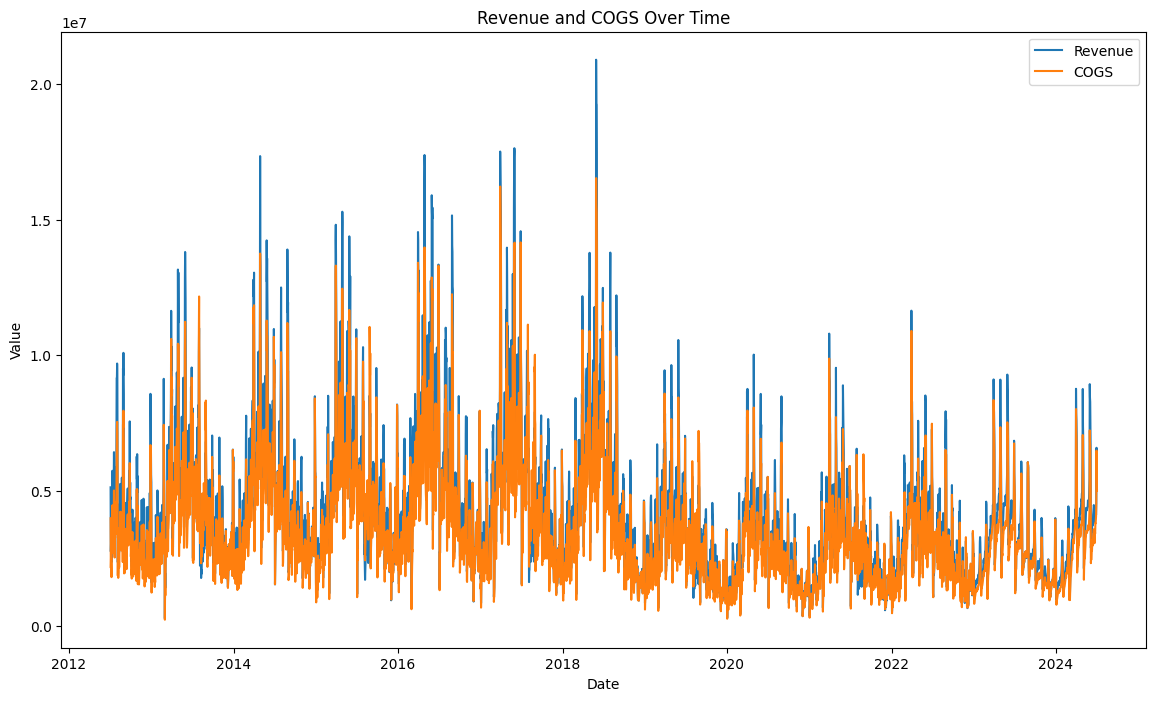

In [8]:
plt.figure(figsize=(14,8))
plt.plot(df['Date'], df['Revenue'], label='Revenue')
plt.plot(df['Date'], df['COGS'], label='COGS')
plt.title('Revenue and COGS Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

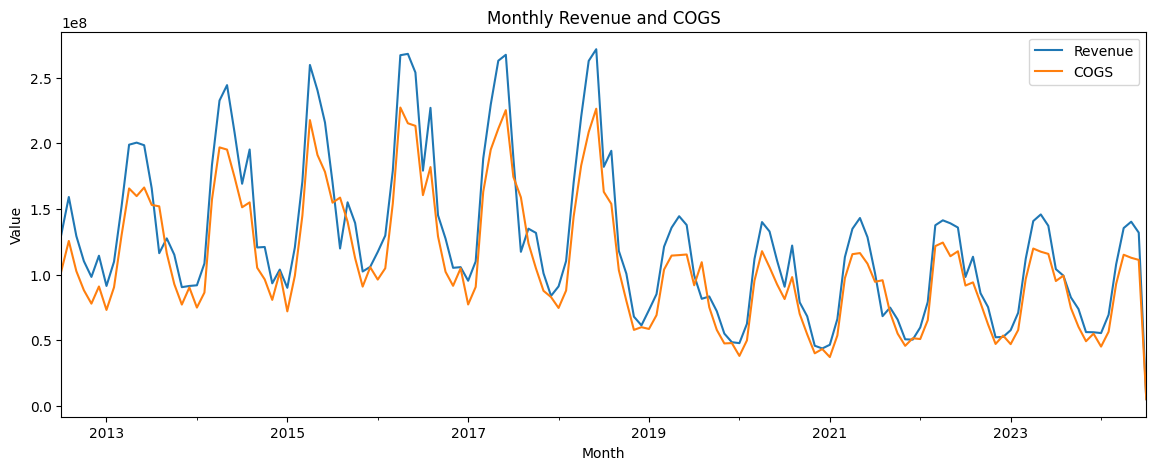

In [9]:
monthly = df.set_index('Date')[['Revenue', 'COGS']].resample('ME').sum()

monthly.plot(figsize=(14,5))
plt.title('Monthly Revenue and COGS')
plt.xlabel('Month')
plt.ylabel('Value')
plt.show()

# Feature Engineering

## Featuring time

In [10]:
# Featuring Calendar
df['days'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['quarter'] = df['Date'].dt.quarter
df['day_of_week'] = df['Date'].dt.day_of_week
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype('int')
df['is_weekend'] = (df['day_of_week'] >= 5).astype('int8')

# Feature special days
df['is_double_day'] = (df['days'] == df['month']).astype('int8')
## holidays in VN
vn_holidays = holidays.VN(years=range(2012, 2025))
df['is_holiday']=(df['Date'].isin(vn_holidays)).astype('int8')

# Feature cyclical
## Month cyclical
df['month_sin'] = np.sin(2* np.pi * df['month']/12)
df['month_cos'] = np.cos(2*np.pi * df['month']/12)

# Day of week cyclical
df['day_of_week_sin'] = np.sin(2* np.pi * df['day_of_week']/7)
df['day_of_week_cos'] = np.cos(2*np.pi * df['day_of_week']/7)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23912\3873222714.py:14: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['is_holiday']=(df['Date'].isin(vn_holidays)).astype('int8')


## Featuring sales

In [11]:
# Lag feature
## sale lag
df['sale_lag_1'] = df['Revenue'].shift(1)
df['sale_lag_7'] = df['Revenue'].shift(7)
df['sale_lag_30'] = df['Revenue'].shift(30)

# Rolling feature
df['rolling_mean_7'] = df['Revenue'].rolling(7).mean()
df['rolling_mean_30'] = df['Revenue'].rolling(30).mean()
df['rolling_max_30'] = df['Revenue'].rolling(30).max()

# Training Model

In [ ]:
# Split to train and test set
train = df[df['is_test'] == 0].copy()
test = df[df['is_test'] == 1].copy()

X_train = train.drop(['Date','is_test','Revenue'],axis =1)
y_train = train['Revenue']
X_test = test.drop(['Date','is_test','Revenue'],axis =1)
y_test = test['Revenue']